# The matching low — does a repeated close really mark support? 🟥🟥
### A simple Japanese candlestick **reversal** figure, measured on 21.5 years of real tape

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Marks_support%3F: Busted](https://img.shields.io/badge/Marks_support%3F-Busted-8b949e?style=flat-square)

Open a candlestick book and you'll meet the **matching low**: the market falls for two days in a row, and both days close at (about) the same price. Chart readers call it "a double-bottom in miniature" — the market tested the exact same price twice and twice failed to break it, so that price must be support, and the decline should **reverse upward**.

So we did the boring, honest thing: found **every** matching low in a basket of 30 big US stocks + SPY over 21.5 years, and measured what actually happened next.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the Bonferroni correction? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** We use a fixed **30-name liquid large-cap + SPY** basket (names still trading today), so this carries **survivorship** — it excludes firms whose "reversal" never came because they kept falling and later delisted. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from matching_low import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real(allow_fetch=False, asof="2026-06-30")
else:
    PANEL = None
print("real basket cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-30', 'years': 21.5, 'n_names': 30, 'fp_quantlab': '75a0fd665f4f', 'fp_basket': 'a63644cb0ca5', 'total_bars': 162180, 'h1': (1, 4600, 0.028, 0.028, 52, 51, 1.69, 1.72, -0.03, 0.519, -0.072, -0.172), 'h5': (5, 4597, 0.245, 0.252, 54, 55, 5.49, 5.67, -0.16, 0.545, 0.145, 0.045), 'h10': (10, 4595, 0.5, 0.529, 56, 57, 7.54, 8.34, -0.48, 0.646, 0.4, 0.3), 'h20': (20, 4586, 1.051, 1.087, 59, 59, 10.55, 11.94, -0.4, 0.628, 0.951, 0.851), 'hit_wilson': {1: (50.4, 53.3), 5: (53.0, 55.8), 10: (55.0, 57.9), 20: (57.5, 60.4)}, 'strict': [(1, 1023, 0.021, -0.21, 0.58, 0.565, -0.079), (5, 1023, 0.351, 1.11, 3.81, 0.18, 0.251), (10, 1023, 0.568, 0.33, 4.84, 0.39, 0.468), (20, 1022, 1.3, 1.15, 6.63, 0.163, 1.2)], 'trend': [(1, 1784, 0.039, 0.37, 1.41, 0.383, -0.061), (5, 1783, 0.27, 0.23, 3.55, 0.416, 0.17), (10, 1783, 0.553, 0.24, 5.25, 0.414, 0.453), (20, 1780, 1.278, 1.28, 8.25, 0.119, 1.178)], 'bonf_k': 30, 'bonf_z': 3.14, 'bonf_survive': 0, 'bonf_top': [('INTC', 100, -0.492, -2.09), ('HD', 149, 0.817, 1.84), ('PFE', 159, -0.272, -1.58)], 'syn_null_mean': 0.13, 'syn_null_sd': 0.93, 'syn_null_fire': 1, 'syn_null_n': 20, 'syn': [(0.0, 0, 1484, 0.081, 0.17, 1.03, 51), (0.002, 4257, 1475, 0.769, 8.32, 9.63, 61), (0.004, 4225, 1456, 1.176, 13.03, 14.48, 66)]}


real basket cache present: True | names: 30


## The answer first

| Question | Answer |
|---|---|
| After a matching low, does the market actually reverse upward? | **Not in any way we can certify.** Buy the next morning and, across 1–20 days, you make almost exactly what you'd have made buying on any ordinary day — no more. |
| Does it at least make money? | **Yes, in raw terms — but that's the trap.** Because stocks drift up over decades, *any* long-only rule looks profitable. The honest question is whether it beats an ordinary day, and it doesn't. |
| Does a near-perfect close-tie work better than a loose match? | **No.** It doesn't sharpen anything — the strict version is just rarer. |
| What if the pattern only counts after a genuine prior decline? | **Still nothing.** |
| Does any single stock secretly carry the pattern? | **No.** Checked individually across all 30 names with enough events, using a stricter statistical bar (so one lucky name can't pass as "the" signal), **0/30** clear it. |

> Two red candles closing at the same price don't mean the market "defended" anything — on the tape it means almost nothing at all.

## 1 · The claim

> *"The **matching low** is two consecutive down candles whose closes land at essentially the same price. If sellers pushed the market to the exact same level twice and couldn't break it, buyers are defending that price — a support level has formed, and the decline should reverse."*

This is straight out of Steve Nison's *Japanese Candlestick Charting Techniques* (the book that brought candles to the West) and is catalogued across the standard candlestick references as one of the simpler reversal figures — unlike most of this desk's candlestick patterns, it makes **no short-side claim**: it is a purely bullish signal. We measure it independently, on our own basket and protocol, and ask the only question that matters: **does the market actually bounce?**

## 2 · So what?

If the matching low really predicted a reversal, it would be a genuinely useful, very common signal — it fires roughly **once every 24 trading days per name** in our basket, far more often than most of the desk's rarer three- and four-candle patterns. A signal that common, if real, could anchor a whole systematic strategy.

But there's a trap built into testing *any* long-only rule on a rising market: stocks drift up over time, with or without a pattern. A naive backtest that just checks "did the price go up afterward?" will say yes almost regardless of what triggered the trade. The only honest question is whether the pattern beats what an ordinary, unconditional day in the same basket would have earned you — and that's exactly what we measure.

## 3 · How would we even know?

We take a fixed **30-name** basket of liquid US large-caps + **SPY** and scan every daily bar from **2005-01-03** to **2026-06-30** (21.5 years). For each name we flag **every** matching low: two consecutive down candles whose closes sit within **0.15%** of each other (a realistic tolerance — exact ties basically never happen on continuous prices). Then, with **no cheating**:

1. **Wait for the close** that confirms the second down candle.
2. **Enter the next morning's open** (one day's lag — you can't trade a bar still forming) and hold **1, 5, 10, or 20** trading days, long only.
3. **Compare fairly** — not to zero (a naive comparison is fooled by the market's own drift), but to what the *same basket* earns on an unconditional day, and to thousands of random "fake signal" picks. If buying after a matching low beats the everyday tide, the legend is real. If it doesn't, the "support level" story is a myth.

## 4 · The teardown — let's actually look

**First, the headline.** Here's the return after a matching low, at each horizon, next to what the *same basket* earns on an ordinary (unconditional) day. A real "support and reversal" signal would show the pattern's bar **beating** the baseline, in green.

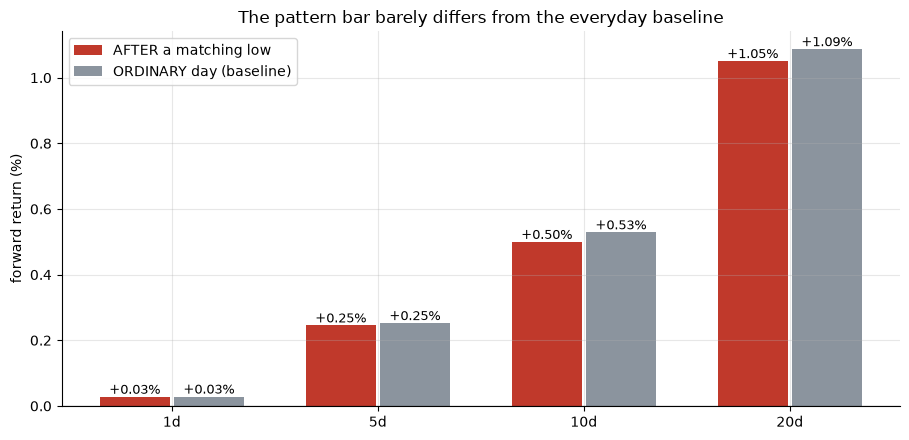

after matching low: {'1d': 0.028, '5d': 0.245, '10d': 0.5, '20d': 1.051}
ordinary day (baseline): {'1d': 0.028, '5d': 0.252, '10d': 0.529, '20d': 1.087}


In [2]:
hs = [1, 5, 10, 20]
if HAVE_REAL:
    rows = {h: st.summarize(PANEL, h, placebo=False) for h in hs}
    means = [rows[h]['mean']*100 for h in hs]
    base  = [rows[h]['base_mean']*100 for h in hs]
else:
    keys = ['h1','h5','h10','h20']
    means = [R[k][2] for k in keys]; base = [R[k][3] for k in keys]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.5))
ax.bar(x-.18, means, .34, color=RED, label='AFTER a matching low')
ax.bar(x+.18, base, .34, color=GREY, label='ORDINARY day (baseline)')
for i,v in enumerate(means): ax.annotate(f'{v:+.2f}%',(i-.18,v),ha='center',va='bottom',fontsize=9)
for i,v in enumerate(base): ax.annotate(f'{v:+.2f}%',(i+.18,v),ha='center',va='bottom',fontsize=9)
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('forward return (%)')
ax.set_title('The pattern bar barely differs from the everyday baseline')
ax.legend(); plt.tight_layout(); plt.show()
print('after matching low:', {f'{h}d': round(m,3) for h,m in zip(hs,means)})
print('ordinary day (baseline):', {f'{h}d': round(b,3) for h,b in zip(hs,base)})

At 20 days the pattern trade is **+1.05%** — positive! — but the ordinary-day baseline is **+1.09%**, essentially the same number. The bars in that chart look almost identical because they *are* almost identical — the pattern isn't adding reversal information, it's riding the same up-drift every other day in the basket rides too.

**Here's the trap, made visible.** If you naively compared the pattern's return to *zero* instead of to the baseline, you'd see a "significant"-looking number and declare victory. Let's look at both.

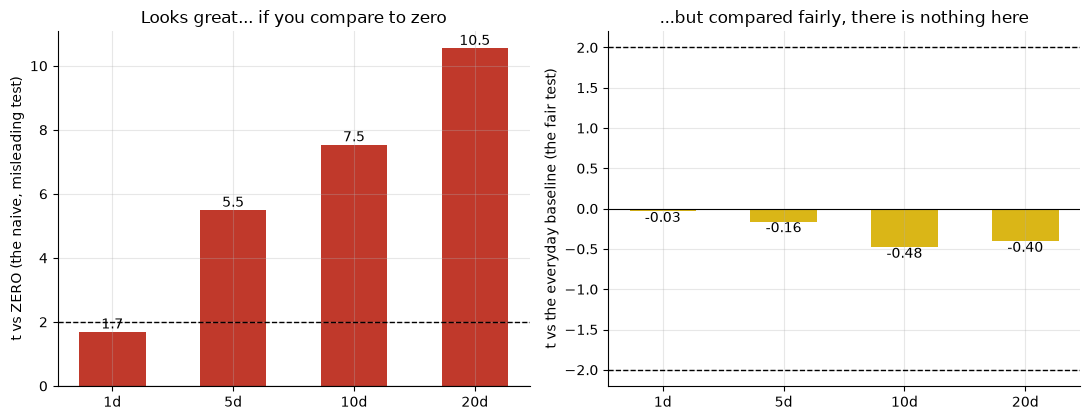

t vs zero: [1.69, 5.49, 7.54, 10.55]
t vs baseline (fair): [-0.03, -0.16, -0.48, -0.4]


In [3]:
if HAVE_REAL:
    t_hac = [rows[h]['t_hac'] for h in hs]
    t_welch = [rows[h]['t_welch'] for h in hs]
else:
    keys = ['h1','h5','h10','h20']
    t_hac = [R[k][6] for k in keys]; t_welch = [R[k][8] for k in keys]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar([f'{h}d' for h in hs], t_hac, color=RED, width=.55)
a1.axhline(2, ls='--', c='k', lw=1); a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('t vs ZERO (the naive, misleading test)')
a1.set_title('Looks great... if you compare to zero')
for i,t in enumerate(t_hac): a1.annotate(f'{t:.1f}',(i,t),ha='center',va='bottom')
a2.bar([f'{h}d' for h in hs], t_welch, color=AMBER, width=.55)
a2.axhline(2, ls='--', c='k', lw=1); a2.axhline(-2, ls='--', c='k', lw=1); a2.axhline(0, c='k', lw=.8)
a2.set_ylabel('t vs the everyday baseline (the fair test)')
a2.set_title('...but compared fairly, there is nothing here')
for i,t in enumerate(t_welch): a2.annotate(f'{t:.2f}',(i,t),ha='center',va='top' if t<0 else 'bottom')
plt.tight_layout(); plt.show()
print('t vs zero:', [round(t,2) for t in t_hac]); print('t vs baseline (fair):', [round(t,2) for t in t_welch])

Left panel: compared to zero, the 20-day number reads *t* = **10.55** — looks like a slam dunk. Right panel: compared to what the basket does on an ordinary day, the same 20-day number reads *t* = **-0.40** — indistinguishable from noise. The left chart was never measuring the pattern. It was measuring the fact that stocks go up over 21 years, which is true whether or not you waited for two matching red candles.

**Could the fair result just be bad luck?** Let's pit the real signal against thousands of **random** picks of the same size, drawn from the same basket.

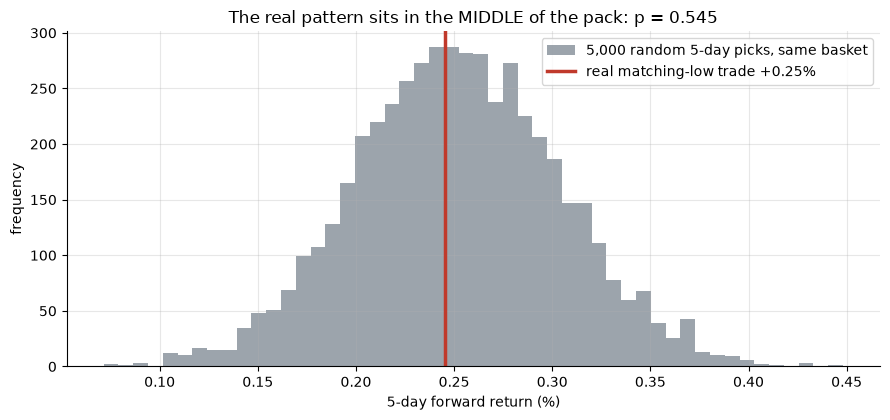

observed +0.25%   share of random picks that beat it: p = 0.545


In [4]:
if HAVE_REAL:
    ev = st.collect_events(PANEL, 5)
    obs = float(ev['ret'].mean())
    pl = st.placebo_pvalue(PANEL, 5, len(ev), obs, n_draws=5000)
    draws = pl['draws']*100; obsp = obs*100; pval = pl['p_value']
else:
    obsp = R['h5'][2]; pval = R['h5'][9]
    rng = np.random.default_rng(694); draws = rng.normal(obsp, 0.5, 5000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='5,000 random 5-day picks, same basket')
ax.axvline(obsp, c=RED, lw=2.5, label=f'real matching-low trade {obsp:+.2f}%')
ax.set_xlabel('5-day forward return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The real pattern sits in the MIDDLE of the pack: p = {pval:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obsp:+.2f}%   share of random picks that beat it: p = {pval:.3f}')

With placebo *p* = **0.545**, more than half of random, undirected picks in the same basket did *at least as well* as the real pattern. That's the signature of no edge at all — the matching low is not special.

**Does a picture-perfect close-tie save it?** Maybe an approximate, casual match is noise but the strict, near-exact tie — or only counting patterns that followed a *genuine* decline — is the real deal. Let's check both stricter recipes against a fair (baseline-matched) comparison.

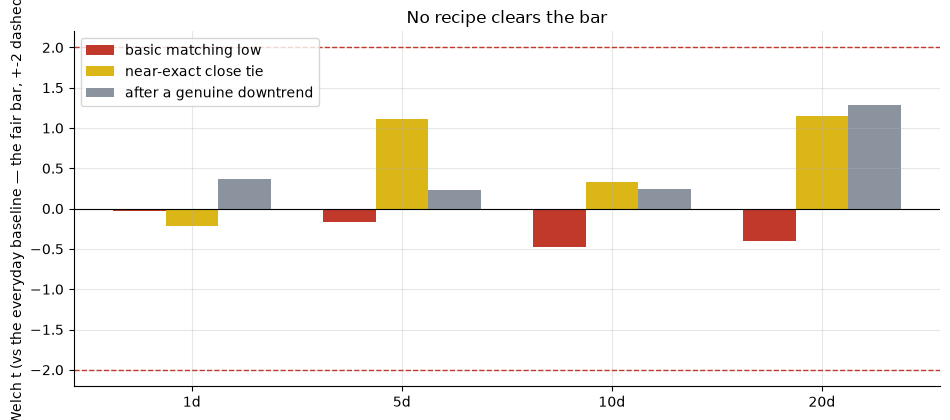

basic t: [-0.03, -0.16, -0.48, -0.4]
strict t: [-0.21, 1.11, 0.33, 1.15]
trend t: [0.37, 0.23, 0.24, 1.28]


In [5]:
if HAVE_REAL:
    basic  = [st.summarize(PANEL, h, placebo=False)['t_welch'] for h in hs]
    strict = [st.summarize(PANEL, h, placebo=False, tol=st.STRICT_TOL)['t_welch'] for h in hs]
    trend  = [st.summarize(PANEL, h, placebo=False, require_downtrend=True)['t_welch'] for h in hs]
else:
    basic  = [R[k][8] for k in ['h1','h5','h10','h20']]
    strict = [s[3] for s in R['strict']]; trend = [t[3] for t in R['trend']]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.6, 4.3))
ax.bar(x-.25, basic, .25, color=RED, label='basic matching low')
ax.bar(x,      strict,.25, color=AMBER, label='near-exact close tie')
ax.bar(x+.25,  trend, .25, color=GREY, label='after a genuine downtrend')
ax.axhline(0, c='k', lw=.8); ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('Welch t (vs the everyday baseline — the fair bar, +-2 dashed)')
ax.set_title('No recipe clears the bar')
ax.legend(); plt.tight_layout(); plt.show()
print('basic t:', [round(b,2) for b in basic]); print('strict t:', [round(s,2) for s in strict]); print('trend t:', [round(t,2) for t in trend])

No bar in that chart pokes above the dashed **+2** line under any of the three recipes. Neither purity filter — a tighter close-tie or a genuine decline behind the pattern — turns "nothing" into "something".

## 5 · The verdict

- **Signal — None.** Measured fairly (against the basket's own unconditional day, not against zero), the matching low never certifies a reversal at any horizon. A random-draw placebo says over half of random picks beat it. No single stock secretly carries it either — **0/30** individual tickers clear a corrected bar. There's no support-and-reversal edge.
- **Tradability — Mirage.** It's *nominally* profitable from 5 days out — but so is doing nothing special in the same basket. There's no excess return to deploy against, and at 1 day, costs already flip it negative.
- **"Marks support"? — Busted.** The famous "tested the same price twice, buyers defended it" reading doesn't survive contact with the tape once you compare it to an ordinary day.

## 6 · Could you actually trade it? — no, and here's the kicker

The trade is already indistinguishable from the baseline before costs. Now add the real-world friction — the round-trip spread. The excess, already zero, stays zero; only the 1-day trade actually turns net-negative.

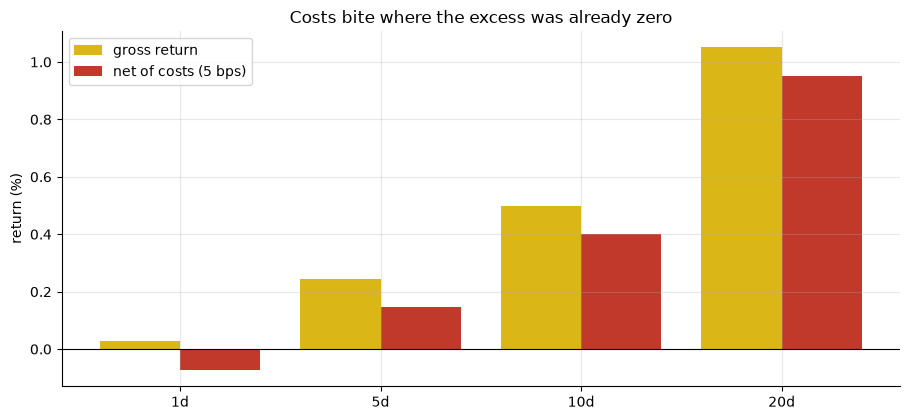

net return by horizon: {'1d': -0.072, '5d': 0.145, '10d': 0.4, '20d': 0.951}


In [6]:
if HAVE_REAL:
    g  = [st.summarize(PANEL, h, placebo=False)['mean']*100 for h in hs]
    n5 = [float(st.event_net_returns(st.collect_events(PANEL, h), cost_bps=5.0).mean())*100 for h in hs]
else:
    keys = ['h1','h5','h10','h20']
    g  = [R[k][2] for k in keys]; n5 = [R[k][10] for k in keys]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, g, .4, color=AMBER, label='gross return')
ax.bar(x+.2, n5, .4, color=RED, label='net of costs (5 bps)')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('return (%)'); ax.set_title('Costs bite where the excess was already zero')
ax.legend(); plt.tight_layout(); plt.show()
print('net return by horizon:', {f'{h}d': round(v,3) for h,v in zip(hs,n5)})

At 1 day the net trade is **-0.07%** — a small loss — and even where the net number is positive (+0.95% at 20 days) it's because the market drifted up over that window generally, not because of the pattern. The matching low is common enough to build a strategy around if it worked — it just doesn't.

## 7 · Going further 🚪

- **Why does the naive comparison fool people?** Any long-only bet in a drifting market looks "significant" against **zero** — with or without a matching low — because the market drifts up on its own. That's why this study's certifying test compares each event to what the *same basket* earns on an ordinary day. The [quants notebook](02_for_the_quants.ipynb) shows this trap live on a synthetic panel with a **known** zero edge.
- **The "same price twice" family.** [409-tweezer-tops-bottoms](../../409-tweezer-tops-bottoms/) tests matching *wick lows*, no color requirement; [460-counterattack-lines](../../460-counterattack-lines/) requires the second candle to be the *opposite* color; [696-double-bottom](../../696-double-bottom/) is the multi-week macro version — none of them run this study's specific two-down-candle, matching-close figure.

*Think a stricter close-tie, a different universe, or a clever filter turns it green? Show the **net** return landing above the basket's own baseline with Welch *t* ≥ 2 — then we'll talk.*